<a href="https://colab.research.google.com/github/mukta774/data/blob/main/knn_for_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Corrected import for seaborn

df = pd.read_csv('car_price_prediction (1) - car_price_prediction (1).csv')

df2 = pd.read_csv('car_price_prediction (1) - car_price_prediction (1).csv')
df.head()
features = df.columns.tolist()

print("~~No. of null values are :~~ ",df.isnull().sum())
for feature in features:
    if df[feature].dtype == 'object':
        df[feature].fillna(df[feature].mode()[0], inplace = True)
    else:
        df.fillna(value = df[feature].mean(), inplace = True)
print("~~No. of null values are : ~~",df.isnull().sum())

print("~~No. of duplicate values are :~~",df.duplicated().sum())
df.drop_duplicates(inplace = True)
print("No. of duplicate values are :",df.duplicated().sum())

~~No. of null values are :~~  Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64
~~No. of null values are : ~~ Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64
~~No. of duplicate values are :~~ 3512
No. of duplicate values are : 0


/tmp/ipython-input-2-3418544085.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(df[feature].mode()[0], inplace = True)


In [ ]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15725 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15725 non-null  float64
 1   Levy              15725 non-null  object 
 2   Manufacturer      15725 non-null  object 
 3   Model             15725 non-null  object 
 4   Prod. year        15725 non-null  float64
 5   Category          15725 non-null  object 
 6   Leather interior  15725 non-null  object 
 7   Fuel type         15725 non-null  object 
 8   Engine volume     15725 non-null  object 
 9   Mileage           15725 non-null  object 
 10  Cylinders         15725 non-null  float64
 11  Gear box type     15725 non-null  object 
 12  Drive wheels      15725 non-null  object 
 13  Doors             15725 non-null  object 
 14  Wheel             15725 non-null  object 
 15  Color             15725 non-null  object 
 16  Airbags           15725 non-null  float64
dty

<bound method NDFrame.describe of           Price  Levy   Manufacturer    Model  Prod. year   Category  \
0      0.282915  1399          LEXUS   RX 450    0.876543       Jeep   
1      0.352821  1018      CHEVROLET  Equinox    0.888889       Jeep   
2      0.179722     -          HONDA      FIT    0.827160  Hatchback   
3      0.076551   862           FORD   Escape    0.888889       Jeep   
4      0.248907   446          HONDA      FIT    0.925926  Hatchback   
...         ...   ...            ...      ...         ...        ...   
19230  0.009956   645         TOYOTA    Prius    0.888889  Hatchback   
19232  0.179722     -  MERCEDES-BENZ  CLK 200    0.740741      Coupe   
19233  0.332866   831        HYUNDAI   Sonata    0.888889      Sedan   
19234  0.554218   836        HYUNDAI   Tucson    0.876543       Jeep   
19236  0.009956   753        HYUNDAI   Sonata    0.901235      Sedan   

      Leather interior Fuel type Engine volume    Mileage  Cylinders  \
0                  Yes    Hyb

/tmp/ipython-input-6-1937696069.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,0.282915,1399,LEXUS,RX 450,0.876543,Jeep,Yes,Hybrid,3.5,186005 km,0.333333,Automatic,4x4,04-May,Left wheel,Silver,0.750
1,0.352821,1018,CHEVROLET,Equinox,0.888889,Jeep,No,Petrol,3,192000 km,0.333333,Tiptronic,4x4,04-May,Left wheel,Black,0.500
2,0.179722,-,HONDA,FIT,0.827160,Hatchback,No,Petrol,1.3,200000 km,0.200000,Variator,Front,04-May,Right-hand drive,Black,0.125
3,0.076551,862,FORD,Escape,0.888889,Jeep,Yes,Hybrid,2.5,168966 km,0.200000,Automatic,4x4,04-May,Left wheel,White,0.000
4,0.248907,446,HONDA,FIT,0.925926,Hatchback,Yes,Petrol,1.3,91901 km,0.200000,Automatic,Front,04-May,Left wheel,Silver,0.250


/tmp/ipython-input-6-1937696069.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = scaler.fit_transform(df[['Price']])


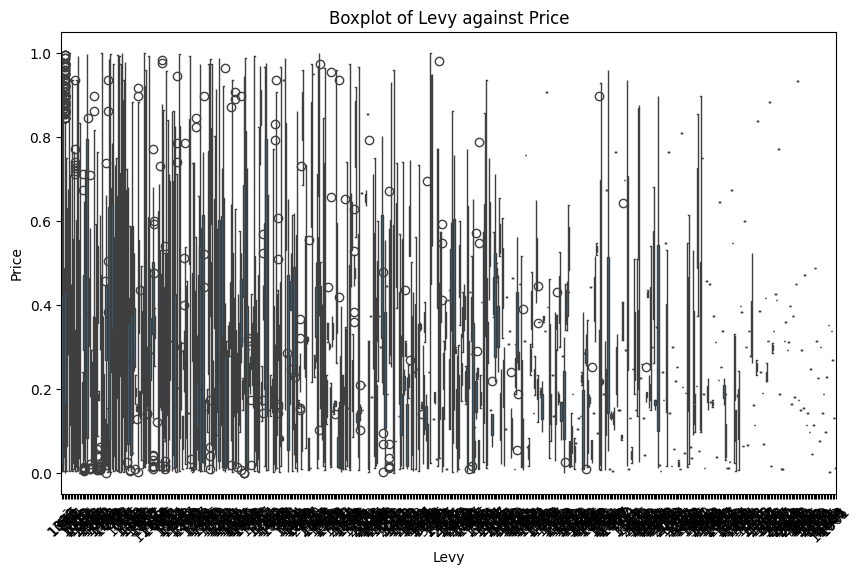

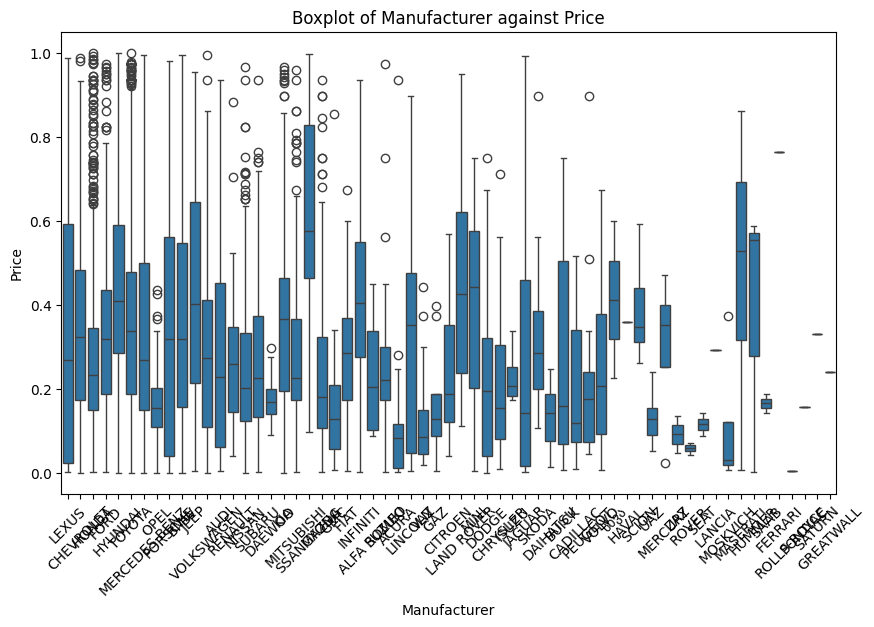

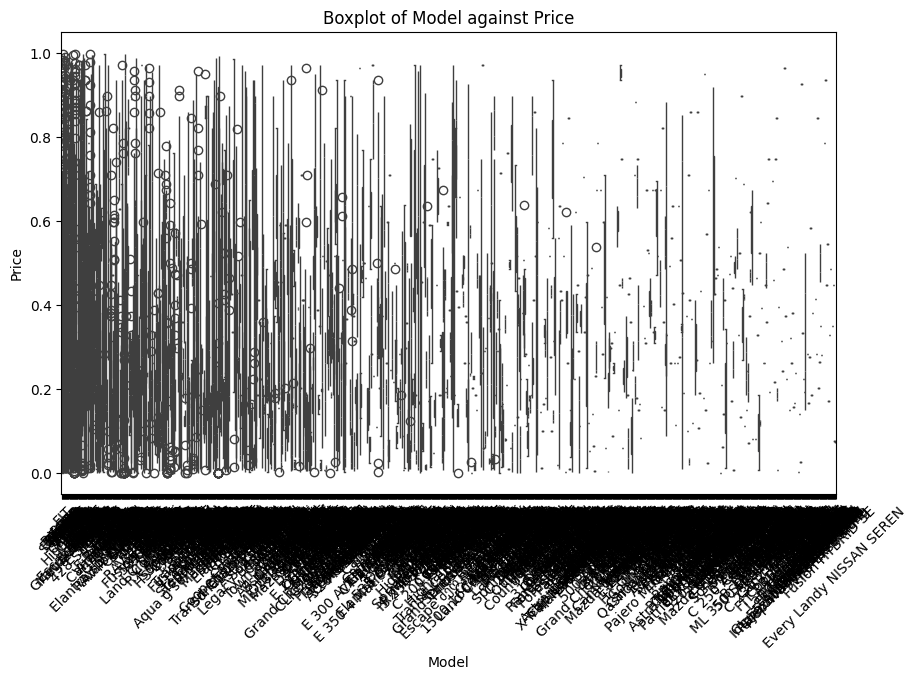

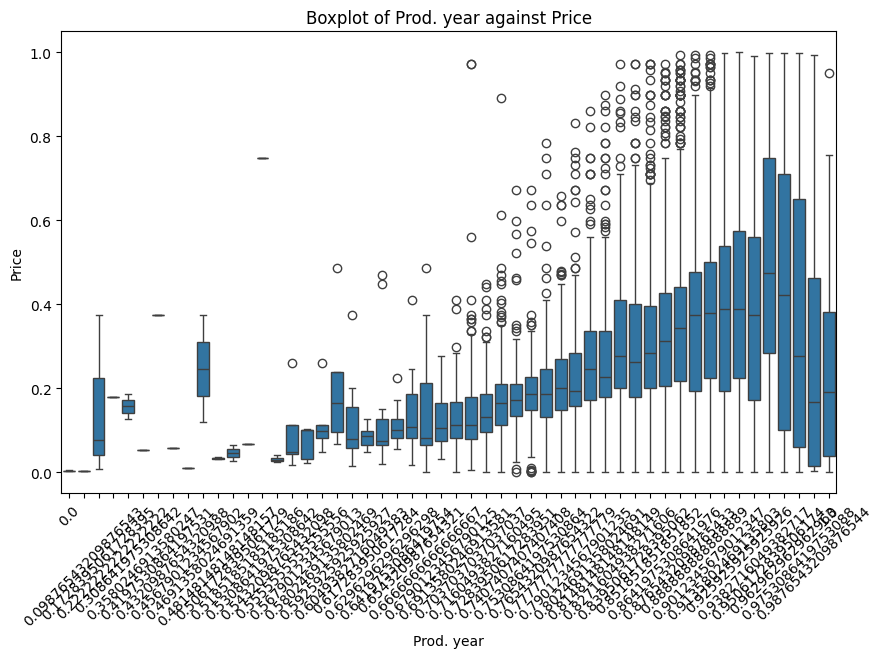

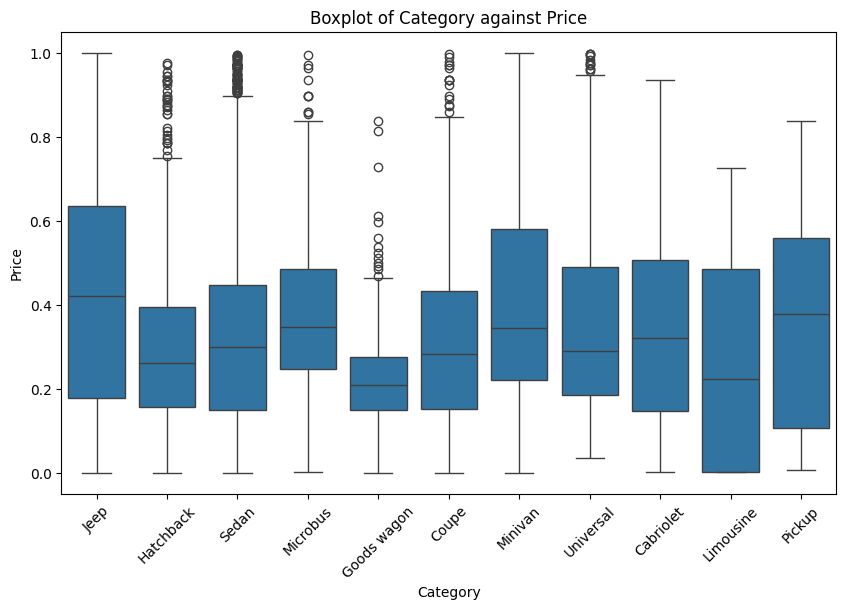

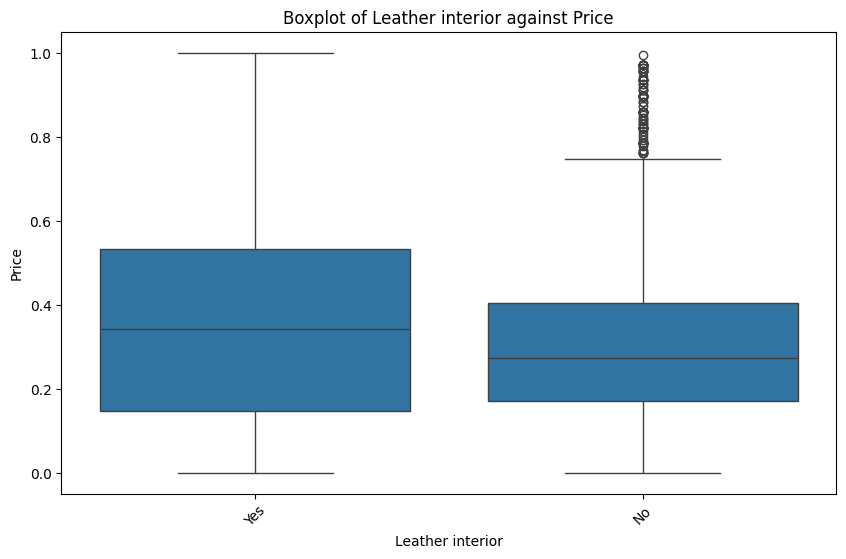

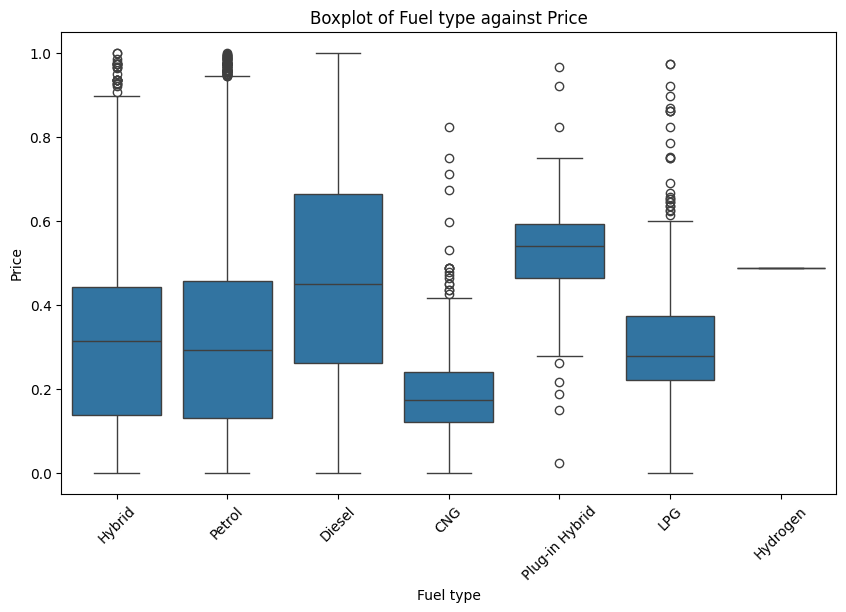

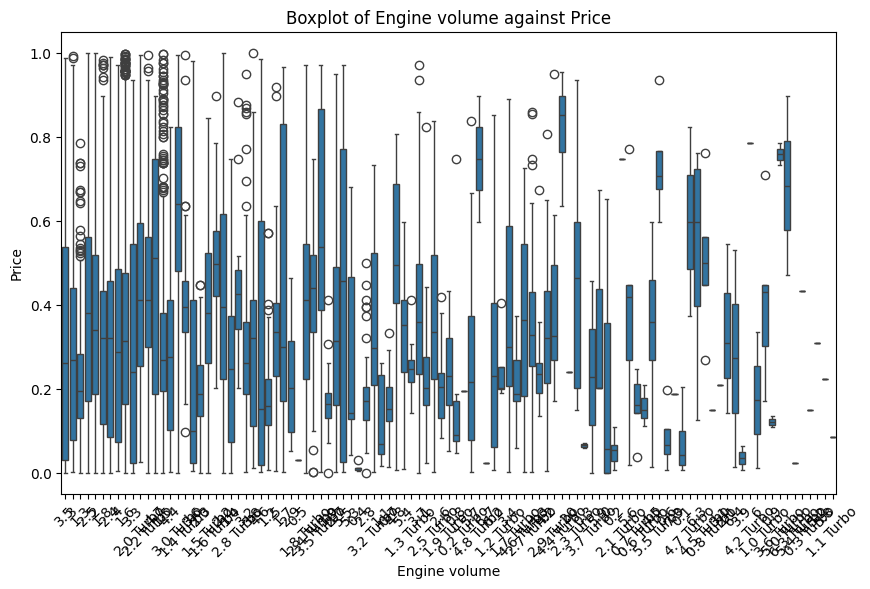

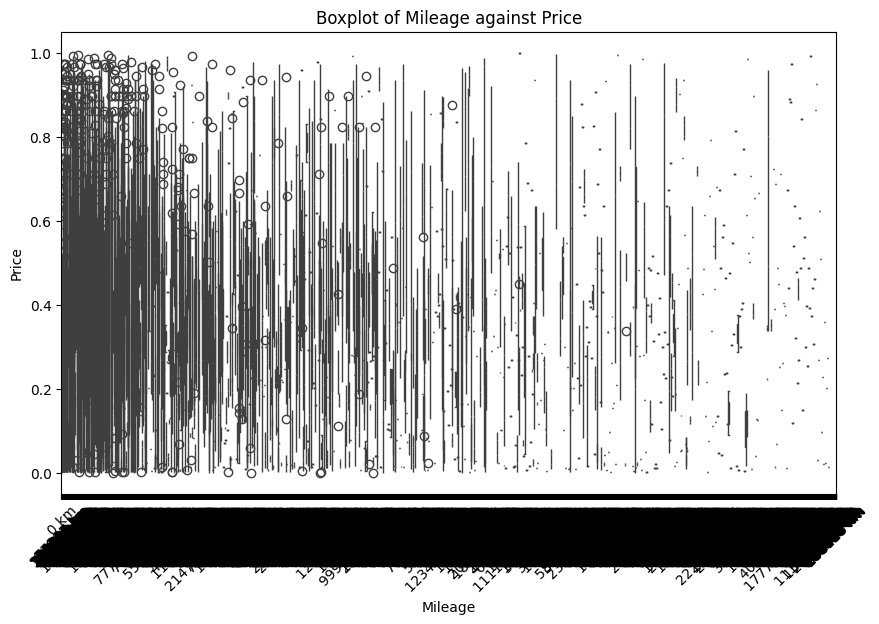

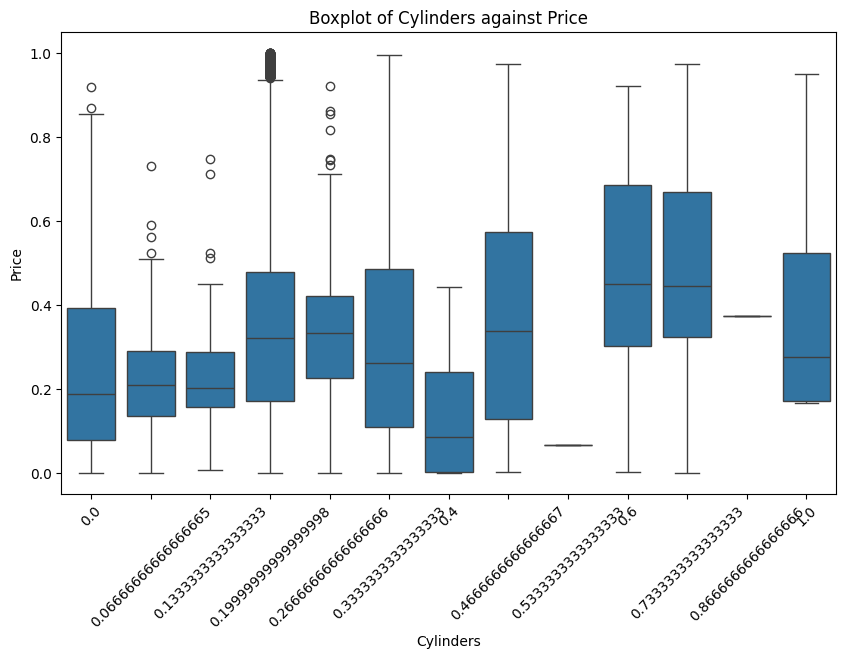

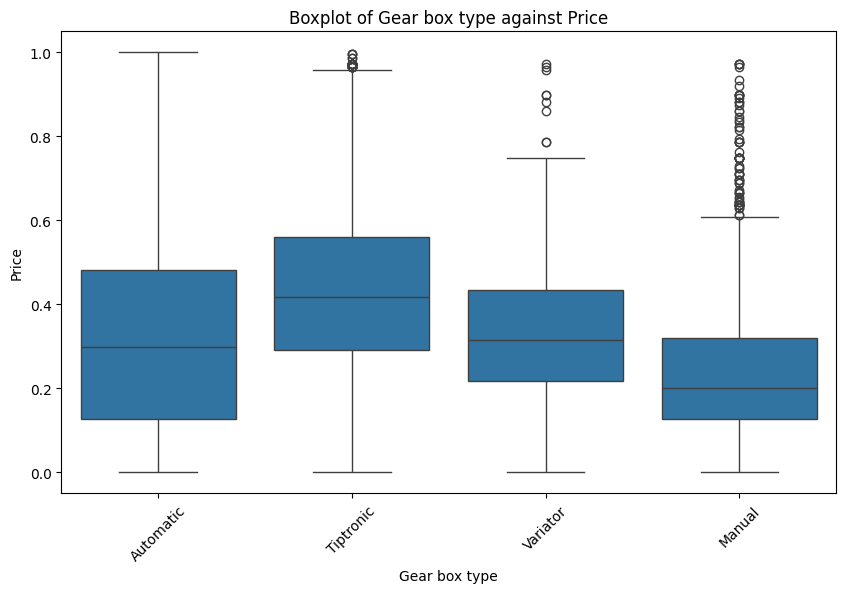

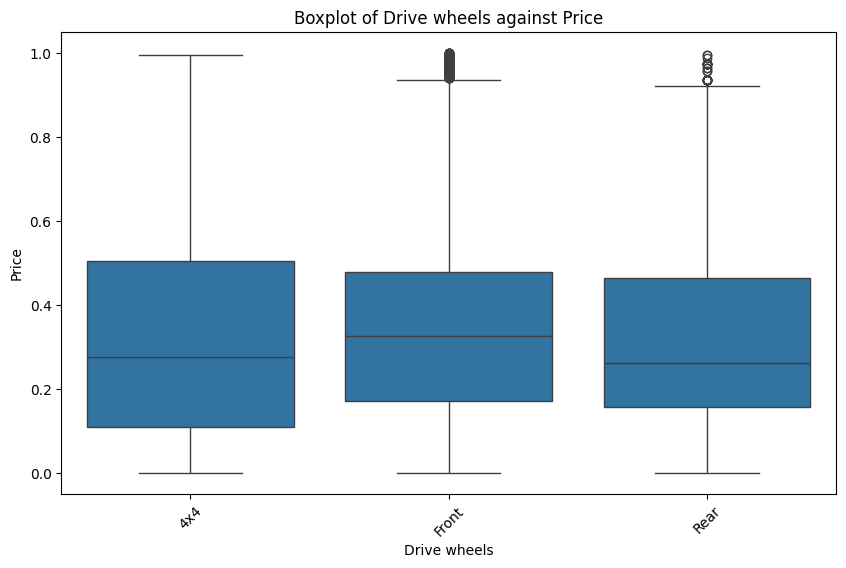

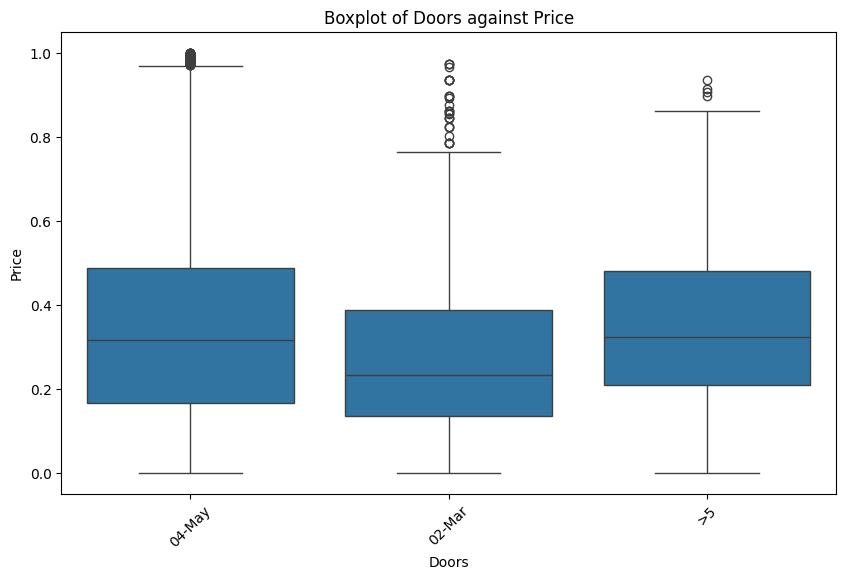

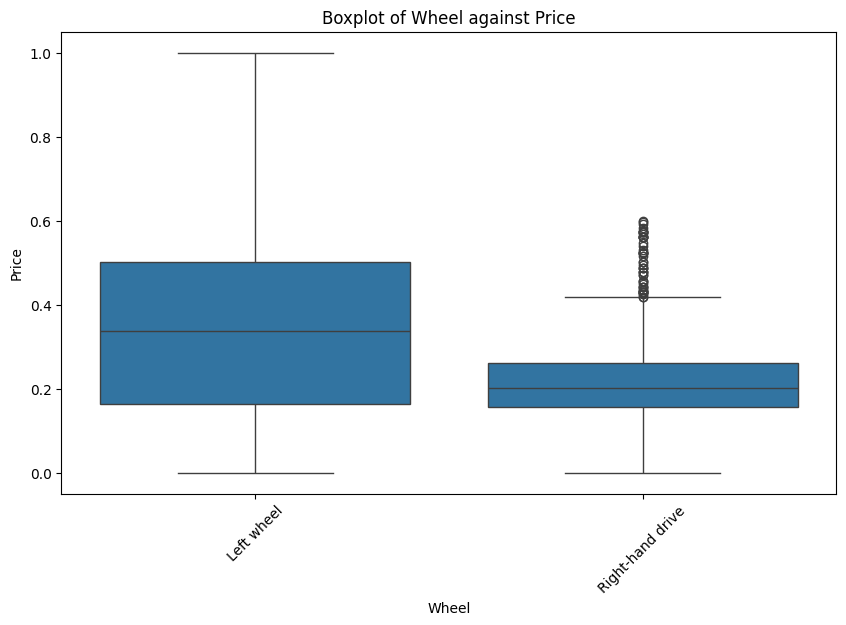

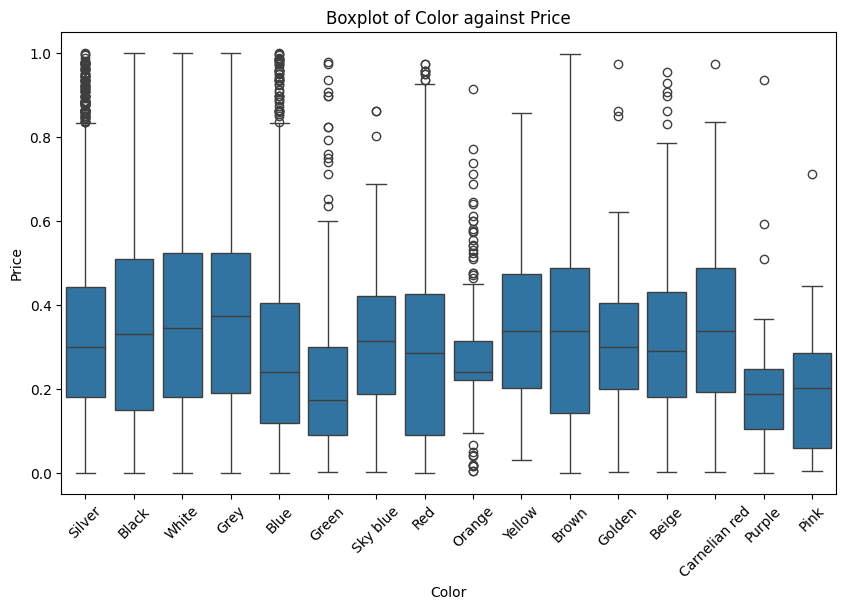

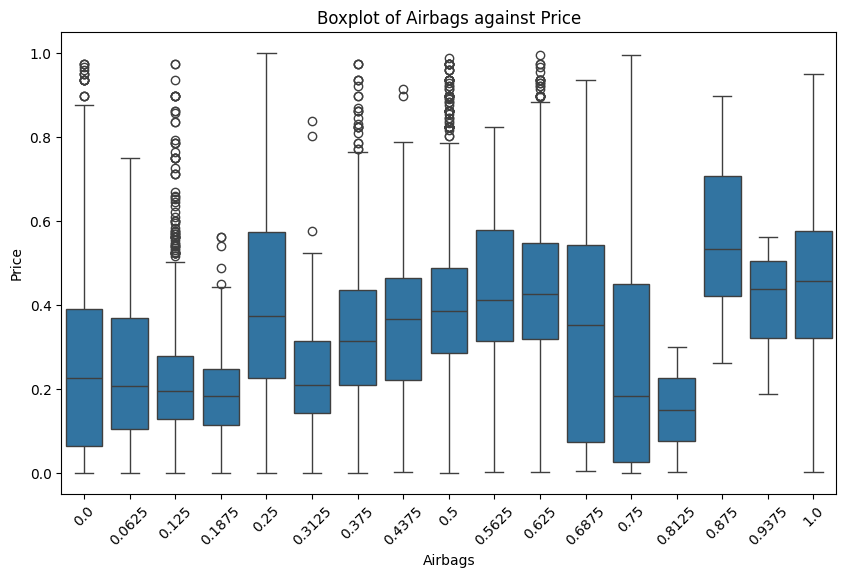

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns excluding the target variable 'Price'
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Price' in numerical_cols:
    numerical_cols.remove('Price')
IQR = df['Price'].quantile(0.75) - df['Price'].quantile(0.25)
lower_bound = df['Price'].quantile(0.25) - 1.5 * IQR
upper_bound = df['Price'].quantile(0.75) + 1.5 * IQR
df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

print(df.describe)
# Apply MinMaxScaler to the numerical columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after scaling numerical features:")
display(df.head())
scaler = MinMaxScaler()

df['Price'] = scaler.fit_transform(df[['Price']])
df.head()

for column in df.columns:
    if column != 'Price':
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=column, y='Price', data=df)
        plt.title(f'Boxplot of {column} against Price')
        plt.xlabel(column)
        plt.ylabel('Price')
        plt.xticks(rotation=45)
        plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Assuming 'df' is your DataFrame and 'Price' is the target variable
# Separate features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Before applying PCA, you may need to handle categorical features
# For simplicity, let's assume all features in X are numerical or have been preprocessed
# If you have categorical features, you'll need to encode them (e.g., using one-hot encoding)

# Select only numerical columns for PCA
X_numerical = X.select_dtypes(include=np.number)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numerical)

print("Original shape:", X_numerical.shape)
print("Shape after PCA:", X_pca.shape)

# Now you can use X_pca and y for your KNN algorithm
# Example (assuming you have split your data into train/test sets):
# X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
# predicted_prices = [predict_knn(X_train_pca, y_train.values, x_test_pca, k=5) for x_test_pca in X_test_pca]

Original shape: (14323, 3)
Shape after PCA: (14323, 2)


In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def predict_knn(X_train, y_train, x_test, k):
    distances = [euclidean_distance(x_test, x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = [y_train[i] for i in k_indices]
    predicted_price = np.mean(k_nearest_labels)
    return predicted_price

# Note: This is a basic implementation using NumPy.
# For a more robust solution, consider using libraries like scikit-learn.
# Also, this implementation assumes numerical features and requires proper data splitting (train/test).